In [56]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import pickle

train_path = r"C:\Users\DS\Documents\smart premium\data\train.csv"
test_path = r"C:\Users\DS\Documents\smart premium\data\test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (1200000, 21)
Test Shape: (800000, 20)


In [19]:
train_df.shape
train_df.columns
train_df.info()
train_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200000 entries, 0 to 1199999
Data columns (total 21 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   id                    1200000 non-null  int64  
 1   Age                   1181295 non-null  float64
 2   Gender                1200000 non-null  object 
 3   Annual Income         1155051 non-null  float64
 4   Marital Status        1181471 non-null  object 
 5   Number of Dependents  1090328 non-null  float64
 6   Education Level       1200000 non-null  object 
 7   Occupation            841925 non-null   object 
 8   Health Score          1125924 non-null  float64
 9   Location              1200000 non-null  object 
 10  Policy Type           1200000 non-null  object 
 11  Previous Claims       835971 non-null   float64
 12  Vehicle Age           1199994 non-null  float64
 13  Credit Score          1062118 non-null  float64
 14  Insurance Duration    1199999 non-

id                           0
Age                      18705
Gender                       0
Annual Income            44949
Marital Status           18529
Number of Dependents    109672
Education Level              0
Occupation              358075
Health Score             74076
Location                     0
Policy Type                  0
Previous Claims         364029
Vehicle Age                  6
Credit Score            137882
Insurance Duration           1
Policy Start Date            0
Customer Feedback        77824
Smoking Status               0
Exercise Frequency           0
Property Type                0
Premium Amount               0
dtype: int64

In [61]:
# COMBINE DATA
full_df = pd.concat([train_df, test_df], axis=0)

# SEPARATE TARGET EARLY
y = train_df["Premium Amount"]
full_df.drop("Premium Amount", axis=1, inplace=True, errors='ignore')

#DROP USELESS COLUMNS
for col in ['id', 'Id', 'ID']:
    if col in full_df.columns:
        full_df.drop(col, axis=1, inplace=True)

if 'Customer Feedback' in full_df.columns:
    full_df.drop('Customer Feedback', axis=1, inplace=True)

In [62]:
# FIX DATE COLUMN
if 'Policy Start Date' in full_df.columns:
    full_df['Policy Start Date'] = pd.to_datetime(full_df['Policy Start Date'], errors='coerce')

    full_df['policy_year'] = full_df['Policy Start Date'].dt.year
    full_df['policy_month'] = full_df['Policy Start Date'].dt.month

    full_df.drop('Policy Start Date', axis=1, inplace=True)

# HANDLE MISSING VALUES
num_cols = full_df.select_dtypes(include=['int64','float64']).columns
full_df[num_cols] = full_df[num_cols].fillna(full_df[num_cols].median())

cat_cols = full_df.select_dtypes(include=['object']).columns
for col in cat_cols:
    full_df[col] = full_df[col].fillna(full_df[col].mode()[0])

In [63]:
# FEATURE ENGINEERING
# Smoking flag
if 'Smoking Status' in full_df.columns:
    full_df['smoking_flag'] = full_df['Smoking Status'].map({'Yes': 1, 'No': 0})
else:
    full_df['smoking_flag'] = 0

# Risk score
full_df['risk_score'] = (
    full_df['Previous Claims'] * 2 +
    full_df['smoking_flag'] * 3 +
    full_df['Health Score']
)

# Income per dependent
full_df['income_per_dependent'] = full_df['Annual Income'] / (full_df['Number of Dependents'] + 1)

# Claims per year
full_df['claims_per_year'] = full_df['Previous Claims'] / (full_df['Insurance Duration'] + 1)
full_df['health_claim_interaction'] = full_df['Health Score'] * full_df['Previous Claims']

# ENCODING

full_df = pd.get_dummies(full_df, drop_first=True)

# Fix column names (LightGBM safe)
full_df.columns = full_df.columns.str.replace(' ', '_')

In [68]:
# SPLIT BACK
train_processed = full_df[:len(train_df)]
test_processed = full_df[len(train_df):]

X = train_processed
import pickle
pickle.dump(X.columns, open("columns.pkl", "wb"))
test_final = test_processed

# SAMPLING 

sample_df = X.copy()
sample_df["target"] = y

sample_df = sample_df.sample(200000, random_state=42)

X = sample_df.drop("target", axis=1)
y = sample_df["target"]


# TRAIN TEST SPLIT

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
# MODEL
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,          # allow deeper trees
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    force_col_wise=True,
    random_state=42
)

model.fit(X_train, y_train)


# EVALUATION
pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred))
r2 = r2_score(y_val, pred)

print("RMSE:", rmse)
print("R2:", r2)

[LightGBM] [Info] Total Bins 1713
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 33
[LightGBM] [Info] Start training from score 1100.666781
RMSE: 852.8828191472334
R2: 0.039480523235537746


In [70]:
# SAVE MODEL
import pickle
pickle.dump(model, open("model.pkl", "wb"))

# TEST PREDICTION
test_preds = model.predict(test_final)

# SUBMISSION FILE
submission = pd.DataFrame({
    "id": test_df["id"],
    "Premium Amount": test_preds
})

submission.to_csv("submission.csv", index=False)

print("Done!")

Done!


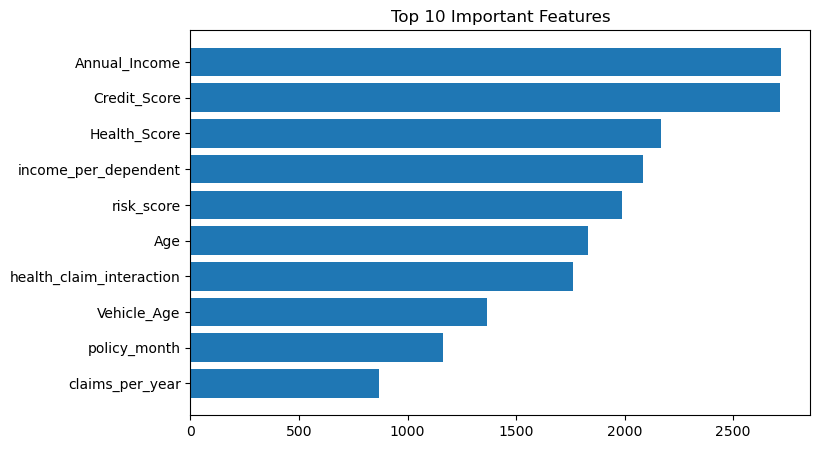

In [71]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()